# Introduction

Celem niniejszego opracowania jest zbudowanie oraz ocena predykcyjnego modelu ryzyka kredytowego typu PD (Probability of Default), tj. modelu estymującego prawdopodobieństwo wystąpienia poważnych opóźnień w spłacie zobowiązania w horyzoncie dwóch lat. W niniejszym opracowaniu skoncentrowano się na budowie dwóch modeli predykcyjnych: 
- model bazowy: regresja logistyczna – standard w bankowości ze względu na interpretowalność, 
- model alternatywny: Random Forest – nieliniowy algorytm pozwalający uchwycić bardziej złożone zależności.

Wyniki modeli porównano na podstawie standardowych metryk stosowanych w ryzyku kredytowym:
AUC oraz Gini, z oceną jakości predykcji na wydzielonym zbiorze testowym.


# Data cleaning

## Sprawdzenie danych

In [3]:
import pandas as pd
import numpy as np

pd.options.display.float_format = '{:.2f}'.format

df = pd.read_csv("../data/cs-training.csv", sep=',', index_col=[0])
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


### Liczność klas

In [4]:
counts = df['SeriousDlqin2yrs'].value_counts()
print(counts)

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


139974 osoby nie doświadczyły opóźnienia w spłacie ≥ 90 dni w okresie najbliższych 24 miesięcy, w przeciwieństwie do 10026 osób (default).

### Udział procentowy

In [5]:
percent = df['SeriousDlqin2yrs'].mean()  
print("Udział defaultów:", percent)

Udział defaultów: 0.06684


6,7% klientów w zbiorze danych doświadczyło w ciągu 2 lat przeterminowania płatności na co najmniej 90 dni.

### Braki w danych

In [7]:
print(df.isna().sum())

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


Zmienna MonthlyIncome ma dużo braków które trzeba usunąć

## Uzupełnianie braków

### Uzupełnienie brakujących dochodów MonthlyIncome medianą, aby braki nie zniekształacały dalszych analiz.

In [8]:
median_income = df.loc[df['MonthlyIncome'] > 0, 'MonthlyIncome'].median()

df['MonthlyIncome'] = df['MonthlyIncome'].replace(0, np.nan)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

print(df.isna().sum())

SeriousDlqin2yrs                           0
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                              0
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      3924
dtype: int64


### Uzupełnienie brakujących dochodów MonthlyIncome

In [9]:
median_NOD = df.loc[df['NumberOfDependents'] > 0, 'NumberOfDependents'].median()

df['NumberOfDependents'] = df['NumberOfDependents'].replace(0, np.nan)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(median_NOD)

print(df.isna().sum())

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [10]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,0.07,6.05,52.30,0.42,353.01,6485.02,8.45,0.27,1.02,0.24,1.95
std,0.25,249.76,14.77,4.19,2037.82,12872.64,5.15,4.17,1.13,4.16,0.63
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
25%,0.00,0.03,41.00,0.00,0.18,4000.00,5.00,0.00,0.00,0.00,2.00
50%,0.00,0.15,52.00,0.00,0.37,5437.00,8.00,0.00,1.00,0.00,2.00
75%,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,2.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


## Clipping 

Robię clipping do 10 dla danych doczycących występowania opóźnień, ponieważ w tych zmiennych pojawiają się nienaturalnie wysokie wartości (np. 96), które najprawdopodobniej są kodami systemowymi. Ograniczenie wartości zapobiega wpływowi ekstremalnych outlierów, które mogłyby zaburzyć rozkład danych i pogorszyć działanie modelu.

In [ ]:
cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for c in cols:
    df[c] = df[c].clip(upper=10)

## Statystyka opisowa

In [49]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,0.07,6.05,52.30,0.26,353.01,6485.02,8.45,0.11,1.02,0.08,1.95
std,0.25,249.76,14.77,0.81,2037.82,12872.64,5.15,0.64,1.13,0.53,0.63
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
25%,0.00,0.03,41.00,0.00,0.18,4000.00,5.00,0.00,0.00,0.00,2.00
50%,0.00,0.15,52.00,0.00,0.37,5437.00,8.00,0.00,1.00,0.00,2.00
75%,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,2.00
max,1.00,50708.00,109.00,10.00,329664.00,3008750.00,58.00,10.00,54.00,10.00,20.00



### **SeriousDlqin2yrs (Zmienna celu)**  
- Zmienna binarna:  
  - `0` – brak defaultu  
  - `1` – opóźnienie ≥ 90 dni  
- Średnia = 0.07, co oznacza udział defaultów na poziomie ~6,7%.  
- Dane są silnie niezbalansowane, co wymaga stosowania metryk typu AUC/Gini oraz ważenia klas.

---

### **RevolvingUtilizationOfUnsecuredLines (wykorzystanie limitów kredytowych)**  
- Średnia ≈ 6.05, mediana 0.15 oznacza że zmienna jest skrajnie prawoskośna.  
- 75% klientów ma wartość ≤ 0.56, ale maksimum to aż 50708.  
- Obecność ekstremów sugeruje błędy raportowania lub specyficzne przypadki (bardzo wysokie limity to bardzo wysokie zadłużenie).  

---

### **age (wiek)**  
- Średnia ≈ 52.3, mediana 52 oznacza rozkład dość symetryczny.  
- Min = 0, max = 109 to wartości podejrzane (wiek 0 = błąd raportowania).  
- Z punktu widzenia ryzyka: starsi klienci zwykle mają niższe ryzyko, co potwierdzają modele.

---

### **Historia opóźnień (30–59 / 60–89 / 90+ dni)**  
- Przykład:  
  - `NumberOfTime30-59` → średnia 0.26, max 10, większość ma 0.  
  - `NumberOfTimes90DaysLate` → średnia 0.11, max 10, mediana 0.  
- Wszystkie trzy zmienne mają 0 jako medianę, ale skrajne maksimum = 10, ale to naturalne. Większość populacji jest „czysta”, ale istnieje grupa klientów z wieloma opóźnieniami, która ma ekstremalnie wysokie ryzyko.  

---

### **DebtRatio (wskaźnik zadłużenia)**  
- Średnia ≈ 353, mediana ≈ 0.37 tutaj gigantyczna różnica.  
- Maksimum = 329 664 wskazuje na problemy z błędami danych / dzieleniem przez bardzo mały dochód.  
- 25–75% klientów jest w zakresie 0.18 – 0.87, czyli sensownie.

---

### **MonthlyIncome (dochód miesięczny)**  
- Średnia = 6485, mediana = 5437 oznacza skośny rozkład z kilkoma bardzo wysokimi wartościami (max = 3 008 750).  
- Min = 1 (po imputacji zera zniknęły).  
- Teraz count = 150 000, ponieważ brakujące wartości **zostały uzupełnione medianą**.  
- To poprawia stabilność modeli i usuwa wcześniej występujące braki (~20%).

---

### **NumberOfOpenCreditLinesAndLoans (liczba aktywnych produktów kredytowych)**  
- Średnia ≈ 8.45, mediana 8, max 58.  
- Typowy klient ma 5–11 produktów, skrajni mają ponad 30–50.  
- Może to świadczyć o:  
  - intensywnym korzystaniu z kredytów,  
  - potencjalnie wyższym ryzyku.

---

### **NumberRealEstateLoansOrLines (nieruchomości / kredyty hipoteczne)**  
- Średnia ≈ 1.02, mediana 1, 75% ≤ 2.  
- Typowy klient ma 0–2 kredyty hipoteczne.

---

### **NumberOfDependents (liczba osób na utrzymaniu)**  
- Średnia = 1.95, mediana = 2, min = 1, max = 20.  
- Rozkład jest skrajnie prawoskośny, ale bardziej realistyczny niż wcześniej (po imputacji zera, mediana skoczyła z 0 do 2).  
- Typowe gospodarstwo domowe ma 1–2 osoby na utrzymaniu.  
- Wysokie wartości (10–20) występują rzadko, ale mogą zwiększać ryzyko z powodu obciążeń finansowych.


# Model

In [35]:
y = df['SeriousDlqin2yrs']
X = df.drop(columns=['SeriousDlqin2yrs'])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

Podział na test i training

## Regresja Logistyczna

### Trening modelu

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Skalowanie danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trening modelu z solverem saga
model = LogisticRegression(max_iter=2000, solver="saga")
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


Model regresji logistycznej został wykorzystany jako model bazowy, ponieważ jest: prosty do interpretacji, stabilny na danych kredytowych, powszechnie stosowany w modelach scorecardowych.

Regresja logistyczna wymaga skalowania zmiennych wejściowych, ponieważ:

- cechy mają bardzo różne skale (np. MonthlyIncome vs RevolvingUtilization),
- solver `saga` (użyty w modelu) gorzej radzi sobie bez normalizacji,
- poprawia to stabilność i zbieżność optymalizacji.


### Predykcja i ocena modelu

In [15]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

Po wytrenowaniu regresji logistycznej dokonano predykcji prawdopodobieństwa defaultu oraz oceny jakości modelu. Do predykcji wykorzystano zeskalowane dane testowe, co zapewnia zgodność ze skalowaniem wykonanym podczas treningu.

### Podstawowe metryki

In [16]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)
print("auc:", auc)

auc: 0.8146702871102153


**AUC 0.81** oznacza bardzo dobrą zdolność separacji klientów dobrych i złych. 

In [17]:
gini = 2 * auc - 1
print("gini:", gini)

gini: 0.6293405742204305


**GINI 0.63** stabilny, silny model na poziomie użyteczności produkcyjnej. 


In [18]:
from sklearn.metrics import confusion_matrix

print("Macierz pomyłek:")
confusion_matrix(y_test, y_pred)

Macierz pomyłek:


array([[34828,   166],
       [ 2230,   276]])


- **TN (34 828)** - poprawnie zaklasyfikowani klienci bez defaultu.  
- **FP (166)** - klienci, którzy w rzeczywistości spłacali, ale model uznał ich za ryzykownych.  
- **FN (2 230)** - najważniejsza grupa z perspektywy ryzyka: klienci, którzy zdefaultowali, ale model ich nie wyłapał.  
- **TP (276)** - poprawnie wykryci klienci z wysokim ryzykiem.


In [19]:
# współczynniki modelu
coeffs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

coeffs.sort_values(by='coefficient', ascending=False).head(15)

,feature,coefficient
6,NumberOfTimes90DaysLate,0.43
2,NumberOfTime30-59DaysPastDueNotWorse,0.42
8,NumberOfTime60-89DaysPastDueNotWorse,0.17
7,NumberRealEstateLoansOrLines,0.10
9,NumberOfDependents,0.02
0,RevolvingUtilizationOfUnsecuredLines,-0.00
5,NumberOfOpenCreditLinesAndLoans,-0.02
3,DebtRatio,-0.10
4,MonthlyIncome,-0.37
1,age,-0.39



Najważniejsze zmienne zwiększające ryzyko (dodatnie współczynniki):

1. **NumberOfTimes90DaysLate** (0.43)  
2. **NumberOfTime30-59DaysPastDueNotWorse** (0.42)  
3. **NumberOfTime60-89DaysPastDueNotWorse** (0.17)  
4. **NumberRealEstateLoansOrLines** (0.10)  
5. **NumberOfDependents** (0.02)
To zmienne bezpośrednio związane z historią opóźnień to bardzo silne predyktory ryzyka.

Najważniejsze zmienne zmniejszające ryzyko (ujemne współczynniki):

1. **age** (−0.39) — starsi klienci częściej dotrzymują terminów.  
2. **MonthlyIncome** (−0.37) — wyższy dochód obniża ryzyko.  
3. **DebtRatio** (−0.10)   
4. **NumberOfOpenCreditLinesAndLoans** (−0.02)


In [30]:
coeffs.sort_values(by='coefficient').head(15)

,feature,coefficient,abs_coef
1,age,-0.39,0.39
4,MonthlyIncome,-0.37,0.37
3,DebtRatio,-0.10,0.10
5,NumberOfOpenCreditLinesAndLoans,-0.02,0.02
0,RevolvingUtilizationOfUnsecuredLines,-0.00,0.00
9,NumberOfDependents,0.02,0.02
7,NumberRealEstateLoansOrLines,0.10,0.10
8,NumberOfTime60-89DaysPastDueNotWorse,0.17,0.17
2,NumberOfTime30-59DaysPastDueNotWorse,0.42,0.42
6,NumberOfTimes90DaysLate,0.43,0.43


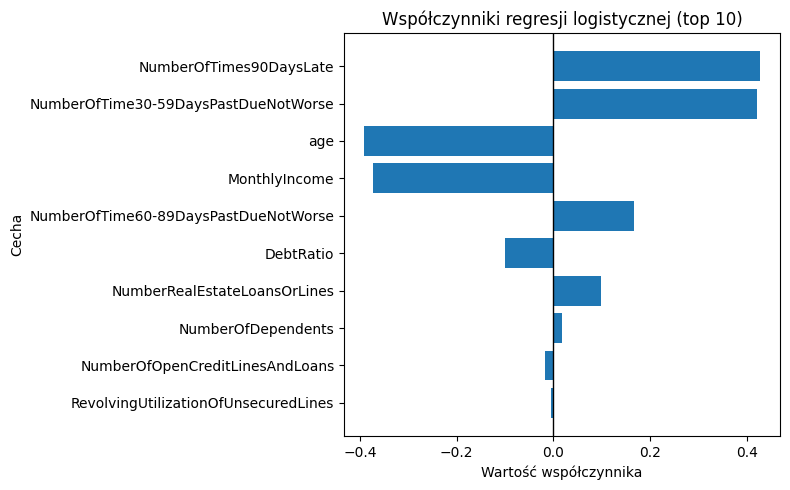

In [33]:
import matplotlib.pyplot as plt
coeffs['abs_coef'] = coeffs['coefficient'].abs()

top = coeffs.sort_values('abs_coef', ascending=True).tail(10)

plt.figure(figsize=(8, 5))
plt.barh(top['feature'], top['coefficient'])
plt.axvline(0, color='black', linewidth=1)
plt.title("Współczynniki regresji logistycznej (top 10)")
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()


Najsilniejsze predyktory to historyczne opóźnienia. Zmienne demograficzne i dochodowe działają stabilizująco i zmniejszają ryzyko. RevolvingUtilization ma współczynnik bliski 0 — w tym modelu została „wyparta” przez silniejsze predyktory (overlap informacji).


## Random Forest

Model Random Forest stanowi nieliniową alternatywę dla regresji logistycznej.  
Jest odporny na outliery, wychwytuje interakcje między zmiennymi oraz nieliniowe zależności, które logit pomija.  
Jego główną zaletą jest wyższa skuteczność predykcyjna kosztem mniejszej interpretowalności.

### Import Random Forest i trenowanie modelu

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [37]:
y = df['SeriousDlqin2yrs']
X = df.drop(columns=['SeriousDlqin2yrs'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

### Trenowanie Random Forest

Random Forest trenowano na danych bez skalowania, ponieważ drzewa decyzyjne nie wymagają normalizacji.

In [38]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### Predykcja i metryki AUC + GINI

In [39]:
rf_pred_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

rf_auc = roc_auc_score(y_test, rf_pred_proba)
rf_gini = 2 * rf_auc - 1

print("AUC:", rf_auc)
print("GINI:", rf_gini)

AUC: 0.8637620456745954
GINI: 0.7275240913491907


**AUC = 0.864** oznacza że model bardzo dobrze separuje klasy (znacznie lepiej niż logit: 0.815).

**Gini = 0.727** to poziom stosowany w produkcyjnych modelach ryzyka. Jest to wzrost jakości o około 0.10 Gini względem regresji logistycznej — bardzo dobry wynik.

### Macierz pomyłek + raport klasyfikacji

In [51]:
print("Macierz pomyłek:")
print(confusion_matrix(y_test, rf_pred))

Macierz pomyłek:
[[27627  7367]
 [  559  1947]]


- TN = 27627 – poprawnie wykryci klienci „dobrzy”.
- FP = 7367 – klienci dobrzy oznaczeni jako ryzykowni (koszt operacyjny).
- FN = 559 – najgorszy przypadek: klienci, którzy zdefaultowali, a model ich nie wykrył.
- TP = 1947 – poprawnie wyłapani klienci ryzykowni.

W porównaniu z logistyczną:

logit miał 2230 FN, Random Forest ma tylko 559 FN.
To gigantyczna poprawa — model nieliniowy wykrył 4x więcej niebezpiecznych klientów. Kosztem tego jest większa liczba FP (fałszywych alarmów).
To klasyczny trade‑off w modelach kredytowych.

In [50]:
print("\nRaport klasyfikacji:")
print(classification_report(y_test, rf_pred))


Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87     34994
           1       0.21      0.78      0.33      2506

    accuracy                           0.79     37500
   macro avg       0.59      0.78      0.60     37500
weighted avg       0.93      0.79      0.84     37500



Klasa 1 (default) ma recall = 0.78, czyli model wykrywa 78% złych klientów.
Dla porównania logit miał recall dla klasy 1 na poziomie ~0.11 (bardzo niski).
Precision = 0.21 oznacza, że część alarmów jest fałszywa, ale FP są tańsi niż FN.

### Feature Importance

In [42]:
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

rf_importance.head(10)


,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.39
6,NumberOfTimes90DaysLate,0.21
2,NumberOfTime30-59DaysPastDueNotWorse,0.19
8,NumberOfTime60-89DaysPastDueNotWorse,0.11
1,age,0.04
5,NumberOfOpenCreditLinesAndLoans,0.02
3,DebtRatio,0.02
7,NumberRealEstateLoansOrLines,0.02
4,MonthlyIncome,0.01
9,NumberOfDependents,0.00


Historia opóźnień (30–59, 60–89, 90+) to najsilniejsze predyktory ryzyka.

W przeciwieństwie do regresji logistycznej, Random Forest uznał RevolvingUtilizationOfUnsecuredLines za ekstremalnie ważną zmienną (przechwycił nieliniowości, outliery i interakcje).

Demografia (wiek) ma mniejszy wpływ, co jest typowe dla modeli ML.

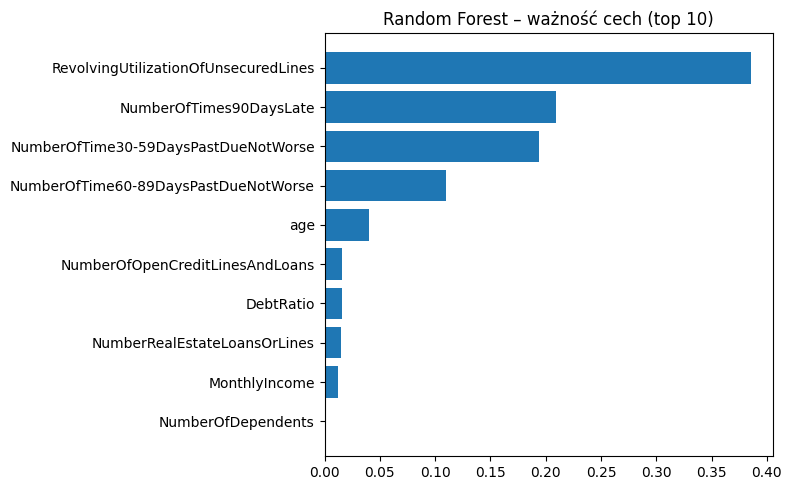

In [44]:

plt.figure(figsize=(8,5))
plt.barh(rf_importance.head(10)['feature'], rf_importance.head(10)['importance'])
plt.title("Random Forest – ważność cech (top 10)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Porównanie LogReg vs Random Forest

In [47]:
comparison = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest'],
    'AUC': [auc, rf_auc],
    'Gini': [gini, rf_gini]
})

comparison

,model,AUC,Gini
0,Logistic Regression,0.81,0.63
1,Random Forest,0.86,0.73


Random Forest osiąga wyraźnie lepsze wyniki — poprawa o **0.05 AUC** i **0.10 GINI**.  
To duży skok jakościowy, szczególnie jak na dane kredytowe.


# Key Findings

Porównano regresję logistyczną i Random Forest w prognozowaniu ryzyka kredytowego. Oba modele dobrze działają, ale Random Forest osiąga wyższą skuteczność dzięki uchwyceniu nieliniowych zależności. Regresja logistyczna jest słabsza predykcyjnie, jednak bardziej przejrzysta i łatwa do interpretacji.

W praktyce, mimo lepszych wyników Random Forest, to regresja logistyczna jest częściej preferowana ze względu na wymogi regulacyjne i większą transparentność.

# Recommendations

Rekomenduje się wykorzystanie Random Forest jako narzędzia pomocniczego do wykrywania nieliniowych zależności i wspierania budowy modelu. Regresja logistyczna może natomiast stanowić bazę modelu produkcyjnego.

Oba modele dają spójne wyniki, co potwierdza poprawność danych i podejścia oraz stanowi dobrą podstawę do dalszego rozwoju modelu PD.